## Practical overview

In this hands-on practical, you will retrieve a PRIDE `.raw` file, convert it to `mzML`, prepare spectra for **InstaNovo**, generate *de novo* peptide-sequence predictions, annotate spectra, and assess prediction confidence and ion coverage. An optional final section calibrates confidence, controls FDR, and performs retained-PSM QC with **winnow**.

**[Open this notebook in Google Colab](https://colab.research.google.com/github/UadKLab/paleoproteomics_summer_school/blob/main/paleoproteomics_instanovo.ipynb)**

*Notebook created by Yun Chiang and Jeroen van Goey.*

# *De novo* sequencing: from a PRIDE `.raw` file to annotated spectra

This is a 45-minute practical that walks you through the following:

1. **Fetch** a Thermo `.raw` file from the PRIDE FTP archive
2. **Convert** `.raw` → `mzML` with **ThermoRawFileParser**
3. **Parse** the `mzML` into a `parquet` for **InstaNovo** CLI and a `mgf` for their Hugging Face space
4. ***De Novo*** predict the spectra with **InstaNovo**
5. **Inspect** predictions and **annotate** spectra with its predicted b/y ions using **spectrum_utils**
6. **Score** predictions with label-free quality **metrics** (confidence & ion coverage)
7. *(optional, advanced)* **Calibrate** confidence and control **FDR** with **winnow**, then **QC** retained PSMs with Winnow metadata

> **Before you start:** set the GPU runtime — *Runtime → Change runtime type → Hardware accelerator → GPU (T4)*

>A Google account may be needed to run notebook cells. You may also click *File → Save a copy in Drive*.

>Our working directory(pwd) is /content/ (default), so no need to mount your own google drive unless you'd like to.

## Step 0 — Setup (run once)
The setup keeps Colab's preinstalled CUDA-enabled PyTorch and installs the workshop dependencies. When it finishes, continue directly to the GPU check below.

In [ ]:
#@title pip install cell (takes c.5 mins)
# Safe to re-run: if InstaNovo already imports, the whole setup is skipped.
try:
    import instanovo  # noqa: F401
    print("InstaNovo already installed - skipping setup. Continue from the GPU check below.")
except ImportError:
    # Keep Colab's preinstalled CUDA/PyTorch stack. InstaNovo 1.2.2 supports torch >=2.5,<2.9.
    # Pin InstaNovo to make the practical reproducible while avoiding a destructive torch reinstall.
    !pip install -q --upgrade-strategy only-if-needed biopython "instanovo[cu126]==1.2.2" pyteomics psims lxml polars pyarrow spectrum_utils ipywidgets
    print("Installation complete. Continue directly to the GPU check below; no runtime restart is needed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.8/213.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.8/487.8 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
#@title >>> Start running from HERE. Check GPU availability for InstaNovo.<<<
import os

import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. In Colab, select Runtime → Change runtime type → T4 GPU, then rerun this cell.")


!nvidia-smi -L 2>/dev/null || echo "No GPU -> Runtime > Change runtime type > GPU"
import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
# Pin down exactly which InstaNovo / InstaNovo+ versions we're running (helps debugging)
!instanovo version

GPU 0: Tesla T4 (UUID: GPU-69ad8e45-99ca-517b-161d-7303a2fd7f51)
torch: 2.6.0+cu126 | CUDA available: True
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Package    ┃ Version     ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ InstaNovo  │ 1.2.2       │
│ InstaNovo+ │ 1.2.2       │
│ NumPy      │ 2.4.6       │
│ PyTorch    │ 2.6.0+cu126 │
└────────────┴─────────────┘


## Step 1 — Fetch a .raw file from PRIDE

Every PRIDE project has a predictable FTP path:

```
https://ftp.pride.ebi.ac.uk/pride/data/archive/<year>/<month>/<accession>/
```
We are going to download a small file from [PXD058287](https://www.ebi.ac.uk/pride/archive/projects/PXD058287):
```
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw (179.7 MB, downloading time: around 1 min)
```

In [ ]:
import os, requests

ACCESSION = "PXD052635"
YEAR, MONTH = "2025", "07"
RAW_NAME = "20180328_QE5_nLC5_MEM_COLLAB_GeoG_1313.raw"
URL = f"https://ftp.pride.ebi.ac.uk/pride/data/archive/{YEAR}/{MONTH}/{ACCESSION}/{RAW_NAME}"
RAW_PATH = RAW_NAME

if not os.path.exists(RAW_PATH):
    print("Downloading", URL)
    with requests.get(URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(RAW_PATH, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
print("RAW size (MB):", round(os.path.getsize(RAW_PATH) / 1e6, 1))

RAW size (MB): 179.7


## Step 2 — Convert Thermo .raw → mzML
`.raw` is Thermo's vendor specific (closed) format. **[ThermoRawFileParser](https://github.com/compomics/ThermoRawFileParser)** is an open-source parser that runs on all platforms to convert `.raw` to open formats: `mzML`/`MGF`. We are using `v.2.0.0-dev` without `Mono` dependency.

The `-f` flag picks the **output format**:

| `-f` | format |
|------|--------|
| 0 | MGF |
| 1 | mzML (plain) |
| 2 | **indexed mzML** — *we use this* |
| 3 | Parquet |
| 4 | none (metadata only) |

We choose **`2` (indexed mzML)**: the embedded index lets a reader jump straight to any spectrum without scanning the whole file, so InstaNovo's `SpectrumDataFrame` loads it quickly. (Plain mzML in option 1 has the same data but no index.)

In [ ]:
%%bash
# Skip the download/unzip if ThermoRawFileParser is already present.
if [ -f ThermoRawFileParser/ThermoRawFileParser ]; then
    echo "ThermoRawFileParser already present - skipping download."
else
    wget -q https://github.com/CompOmics/ThermoRawFileParser/releases/download/v.2.0.0-dev/ThermoRawFileParser-v.2.0.0-dev-linux.zip
    unzip -q ThermoRawFileParser-v.2.0.0-dev-linux.zip -d ThermoRawFileParser && rm ThermoRawFileParser-v.2.0.0-dev-linux.zip
    echo "ThermoRawFileParser downloaded."
fi

ThermoRawFileParser downloaded.


In [ ]:
import os

# Reuse RAW_PATH from Step 1 so the filename lives in exactly one place.
# ThermoRawFileParser writes the .mzML next to the input with the same base name.
MZML_PATH = RAW_PATH.replace(".raw", ".mzML")
fmt = 2  # 0=MGF, 1=mzML (plain), 2=indexed mzML

# Skip the conversion if the .mzML already exists.
if os.path.exists(MZML_PATH):
    print(f"{MZML_PATH} already exists - skipping conversion.")
else:
    !ThermoRawFileParser/ThermoRawFileParser -i "{RAW_PATH}" -f "{fmt}" -z

=2026-07-29 20:42:14 INFO Started parsing 20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-07-29 20:42:15 INFO Processing 9917 MS scans
10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 

2026-07-29 20:42:31 INFO Finished parsing 20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-07-29 20:42:32 INFO Processing completed 0 errors, 0 warnings


## Step 3 — Parse the mzML
We are going to see what's inside a `mzML` by using InstaNovo's `SpectrumDataFrame`. `.parquet` is like a `.csv` but smaller to store and faster for a computer to process.

In [ ]:
import pandas as pd
from instanovo.utils.data_handler import SpectrumDataFrame

sdf1 = SpectrumDataFrame.load(MZML_PATH, lazy=False, is_annotated=False)
df = sdf1.to_pandas()
print(f"Parsed {len(df)} spectra | columns: {list(df.columns)}")
df.head()  # show a preview, not all rows (the mz/intensity arrays are large)

/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


Parsed 8853 spectra | columns: ['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array', 'experiment_name']


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array,experiment_name
0,6,,1705.768895,853.891724,2,0.036581,"[115.26212310791016, 120.08121490478516, 138.7...","[1531.368896484375, 3489.806884765625, 1258.18...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
1,7,,948.534520,475.274536,2,0.038742,"[165.88584899902344, 209.11793518066406, 263.7...","[1227.3123779296875, 1877.300537109375, 1068.0...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
2,8,,1722.797826,862.406189,2,0.040933,"[126.2745361328125, 141.3558807373047, 203.858...","[1408.305908203125, 1389.77490234375, 1384.296...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
3,10,,946.509191,474.261871,2,0.048800,"[140.41928100585938, 163.00881958007812, 164.8...","[1225.0076904296875, 1150.8607177734375, 1249....",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
4,11,,1316.515007,439.845612,3,0.050944,"[197.87615966796875, 217.11524963378906, 217.1...","[1342.667724609375, 2023.048828125, 2312.31445...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...


For this workshop we select a **subset of 100 spectra** to keep runtimes short.

Rather than the first 100 scans — which elute early and are mostly low quality — we take **charge 2–3** precursors as a **mix of the 50 most intense + 50 random** spectra. The most-intense alone are dominated by a few very abundant peptides (lots of duplicates); adding a random half gives **diverse peptides and a spread of confidence** (some easy, some hard) — useful for the metrics and FDR steps later.

In [ ]:
import numpy as np

# The first scans elute early and are mostly low quality. Instead, build a
# 100-spectrum subset with a MIX of quality, for diverse peptides AND a spread
# of confidence: the most-intense (top-TIC) spectra alone are dominated by a
# few very abundant peptides (lots of duplicates). Keep charge 2-3 (best for
# de novo); take 50 most intense + 50 random.
dfq = df[df["precursor_charge"].isin([2, 3])].copy()
dfq["_tic"] = dfq["intensity_array"].map(lambda a: float(np.sum(a)))
top  = dfq.sort_values("_tic", ascending=False).head(50)
rand = dfq.drop(top.index).sample(n=50, random_state=0)   # random_state -> reproducible
df1  = (pd.concat([top, rand]).drop(columns="_tic")
          .sample(frac=1, random_state=0)                 # shuffle so it isn't quality-sorted
          .reset_index(drop=True))
print(f"selected {len(df1)} spectra: 50 most intense + 50 random (charge 2-3) | median peaks/spectrum: {int(df1['mz_array'].map(len).median())}")

selected 100 spectra: 50 most intense + 50 random (charge 2-3) | median peaks/spectrum: 137


In [ ]:
from pyteomics import mgf
import numpy as np

def df_to_mgf(df, out_path):
    spectra = []
    for _, row in df.iterrows():
        params = {
            "title":       f"{row['experiment_name']}:scan:{int(row['scan_number'])}",
            "pepmass":     float(row["precursor_mz"]),
            "charge":      f"{int(row['precursor_charge'])}+",
            "rtinseconds": float(row["retention_time"]) * 60.0,
            "scans":       int(row["scan_number"]),
        }
        seq = row.get("sequence")
        if seq is not None and str(seq).strip() not in ("", "nan", "None"):
            params["seq"] = str(seq)

        spectra.append({
            "m/z array":       np.asarray(row["mz_array"],        dtype=float),
            "intensity array": np.asarray(row["intensity_array"], dtype=float),
            "params":          params,
        })

    mgf.write(spectra, out_path, file_mode="w")
    return f"Converted dataframe to MGF file: {out_path}"

We then write our subset to both `.parquet` (for the CLI) and `.mgf` (for the Hugging Face space).

In [ ]:
df1["spectrum_id"] = df1["experiment_name"].astype(str) + ":" + df1["scan_number"].astype(str)
df1.to_parquet("subset_100.parquet")
print("Converted dataframe to parquet file: subset_100.parquet")
print(df_to_mgf(df1, "subset_100.mgf"))

Converted dataframe to parquet file: subset_100.parquet
Converted dataframe to MGF file: subset_100.mgf


## Step 4 — Run InstaNovo for *de novo*
**[InstaNovo](https://github.com/instadeepai/InstaNovo)** is a transformer model that is well-annotated and easy to run. We run it to get a peptide sequence per spectrum, written to `preds.csv` (columns include `predictions`, the sequence confidence `log_probs`, per-residue `token_log_probs`, and beam-search columns).
>
- option A: For Google account users, you may run it here using the CLI (command line interface).
- option B: Go to InstaNovo [Hugging Face space](https://huggingface.co/spaces/InstaDeepAI/InstaNovo) and run the `subset_100.mgf` we made in Step 3 online. <br />(note **not the `.mzML`** since it may be too big)

> InstaNovo also ships **InstaNovo+**, a diffusion model that *refines* the transformer output (`instanovo predict ... --with-refinement`). We skip it here to keep the workshop fast; see the [InstaNovo getting-started notebook](https://github.com/instadeepai/InstaNovo/blob/main/notebooks/getting_started_with_instanovo.ipynb) to try it.

In [ ]:
!instanovo predict --help

                                                                                
 Usage: instanovo predict [OPTIONS] [OVERRIDES]...                              
                                                                                
 Run predictions with InstaNovo and optionally refine with InstaNovo+.          
                                                                                
 First with the transformer-based InstaNovo model and then optionally refine    
 them with the diffusion based InstaNovo+ model.                                
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --data-path             -d                      TEXT  Path to input data     │
│                                                       file                   │
│ --output-path           -o                      FILE  Path to output file.   │
│ --instanovo-model       -i

In [ ]:
# Run the transformer model for de novo sequencing.
# (--no-refinement: skip the InstaNovo+ diffusion step to keep the workshop fast.)
!instanovo predict --data-path subset_100.parquet --output-path preds.csv --denovo --no-refinement

[07/29/26 20:43:41] INFO     Initializing InstaNovo inference.                                                                                                                 
[07/29/26 20:43:44] INFO     NumExpr defaulting to 2 threads.                                                                                                                  
2026-07-29 20:43:48.910599: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-07-29 20:43:52,042:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


## Step 5 — Inspect predictions and annotate spectra
We will pick *de novo* predictions from a list of top and bottom 10 spectra (sorted by model confidence), and visualise them using mirrored plots to see if observed b/y ions matched predicted ones. Generally, higher the ion coverage (observed/predicted ions), the better.

This is *real* data with **no ground-truth peptide labels**, so we can't compute recall/precision — we use confidence and b/y ion coverage as quality proxies instead (quantified in Step 6).

In [ ]:
import matplotlib.pyplot as plt
import spectrum_utils.spectrum as sus
import spectrum_utils.plot as sup
from spectrum_utils import proforma
from spectrum_utils.fragment_annotation import get_theoretical_fragments
%matplotlib inline

In [ ]:
PARQUET = "subset_100.parquet"
#change fragment ion tolerance here
TOL, TOL_MODE = 10, "ppm"

preds   = pd.read_csv("preds.csv")
spectra = pd.read_parquet(PARQUET)

seq_col  = next((c for c in ["predictions","prediction","sequence","peptide"] if c in preds.columns), preds.columns[0])
conf_col = next((c for c in ["log_probs","log_probabilities","confidence"] if c in preds.columns), None)
if conf_col is not None:
    preds["model_confidence"] = np.clip(np.exp(preds[conf_col]), 0, 1)

cand = preds.sort_values(conf_col, ascending=False) if conf_col else preds
cols = ["scan_number", seq_col, conf_col, "model_confidence"]

print("==TOP 10 (most confident)==")
print(cand[cols].head(10).to_string(index=False))

print("\n==BOTTOM 10 (least confident)==")
print(cand[cols].tail(10).to_string(index=False))

==TOP 10 (most confident)==
 scan_number predictions  log_probs  model_confidence
        2166    LIVTQTMK  -0.000084          0.999916
        2238    LIVTQTMK  -0.000133          0.999867
        2251    LIVTQTMK  -0.000151          0.999849
        2178    LIVTQTMK  -0.000157          0.999843
        2091    LIVTQTMK  -0.000205          0.999795
        2264    LIVTQTMK  -0.000213          0.999787
        2212    LIVTQTMK  -0.000226          0.999774
        2143    LIVTQTMK  -0.000277          0.999723
        2290    LIVTQTMK  -0.000286          0.999714
        2277    LIVTQTMK  -0.000446          0.999555

==BOTTOM 10 (least confident)==
 scan_number                             predictions  log_probs  model_confidence
        9532                  YVLQLLVTKPGEDFAVAEALTK -13.774187      1.042189e-06
        5570                 KLLAEKYTKLPAVFKLDALNENK -13.990720      8.392814e-07
        8457    [UNIMOD:1]-GSFNPGGAHEEQC[UNIMOD:4]HI -14.446985      5.318070e-07
        6372     

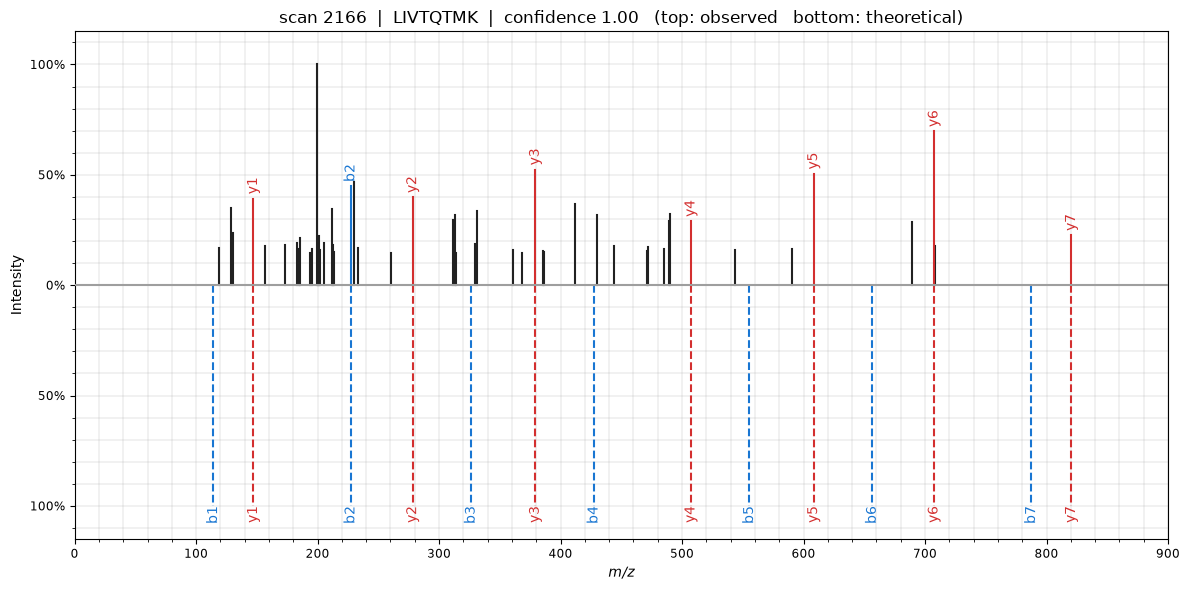

In [ ]:
def show_mirror(scan_number=None):
    """Pass a scan_number from the list above; None = highest confidence."""
    if scan_number is None:
        row = cand.iloc[0]
    else:
        sel = cand[cand["scan_number"] == scan_number]
        if sel.empty:
            print(f"scan {scan_number} not found in predictions - pick one from the lists above.")
            return
        row = sel.iloc[0]
    peptide, scan = str(row[seq_col]), int(row["scan_number"])
    conf = float(row["model_confidence"]) if "model_confidence" in row else None
    sp = spectra.loc[spectra["scan_number"] == scan].iloc[0]
    pmz, z = float(sp["precursor_mz"]), int(sp["precursor_charge"])

    obs = sus.MsmsSpectrum(str(scan), pmz, z,
                           np.asarray(sp["mz_array"], float), np.asarray(sp["intensity_array"], float))
    obs = (obs.set_mz_range(100, 1500).remove_precursor_peak(TOL, TOL_MODE)
              .filter_intensity(0.01, 50).scale_intensity("root")
              .annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by"))

    proteoform = proforma.parse(peptide)[0]
    frags = get_theoretical_fragments(proteoform, ion_types="by", max_charge=1)
    frag_mz = np.array([mz for _, mz in frags])
    theo = sus.MsmsSpectrum(f"{peptide} (theoretical)", pmz, z,
                            frag_mz, np.full(len(frag_mz), obs.intensity.max()))
    theo = theo.annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by")

    fig, ax = plt.subplots(figsize=(12, 6))
    sup.mirror(obs, theo, ax=ax)

    # Restyle the lower (theoretical, negative-y) half of the mirror plot as
    # dashed lines. This pokes at matplotlib artists directly, so it may need
    # updating if spectrum_utils / matplotlib change how they draw peaks.
    for line in ax.lines:
        yd = line.get_ydata()
        if len(yd) and np.min(yd) < -1e-9:
            line.set_linestyle("--")
    for coll in ax.collections:
        segs = coll.get_segments()
        if segs and min(s[:, 1].min() for s in segs) < -1e-9:
            coll.set_linestyle("--")

    conf_str = f"  |  confidence {conf:.2f}" if conf is not None else ""
    ax.set_title(f"scan {scan}  |  {peptide}{conf_str}   (top: observed   bottom: theoretical)")
    plt.tight_layout(); plt.show()

# highest-confidence prediction
show_mirror()

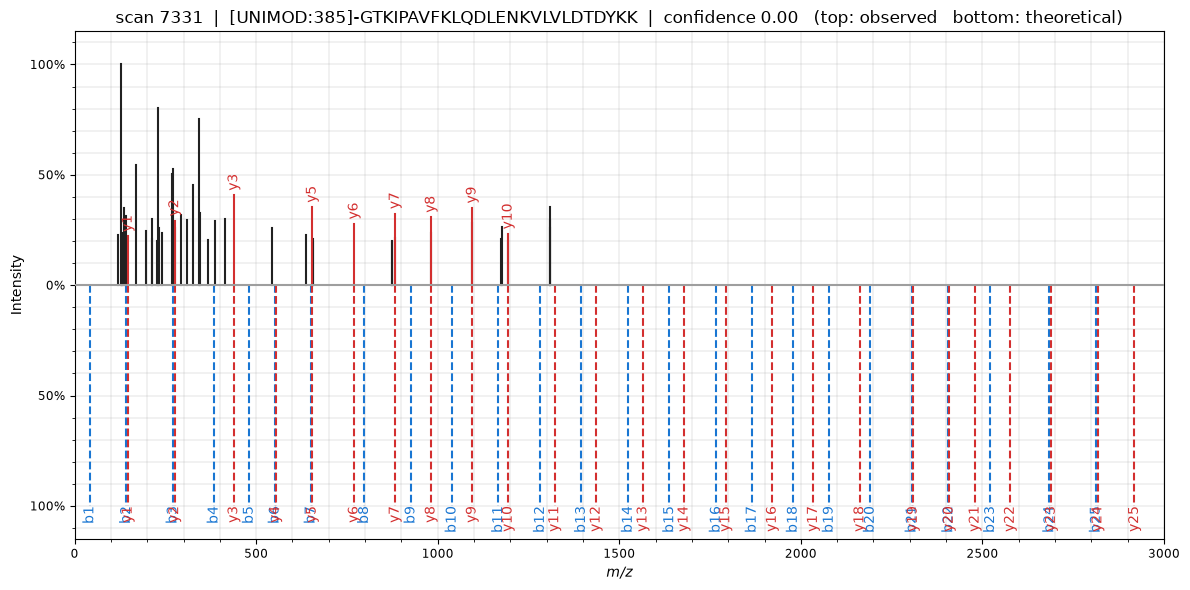

In [ ]:
# show_mirror() above used the most-confident prediction. You can pass any
# scan_number from the TOP/BOTTOM lists above. Scan numbers depend on the
# (random) subset, so here we pick the LEAST-confident one to contrast.
show_mirror(int(cand.iloc[-1]["scan_number"]))

Show the first few predictions.

In [ ]:
preds.head()

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,predictions_token_log_probabilities_beam_2,predictions_beam_3,predictions_log_probability_beam_3,predictions_token_log_probabilities_beam_3,predictions_beam_4,predictions_log_probability_beam_4,predictions_token_log_probabilities_beam_4,predictions_tokenised,delta_mass_ppm,model_confidence
0,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,2130,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,467.275269,2,0,LIVTQTMK,-0.000579,"[-0.0004447901446837932, -8.034383063204587e-0...",no_group,...,"[-6.079655122448457e-06, -9.429767608642578, -...",[UNIMOD:385]LIVTQTM[UNIMOD:35]K,-34.769547,"[-22.328876495361328, -0.031207941472530365, -...",LIVSQTMK,-12.982220,"[-0.040765419602394104, -0.0002369599969824776...","L, I, V, T, Q, T, M, K",0.559510,0.999421
1,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,4757,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,842.895081,2,1,LDQWLGMRPGY[UNIMOD:21]EK,-3.717503,"[-0.004402943886816502, -3.480850500636734e-05...",no_group,...,"[-4.935142715112306e-05, -0.000160681214765645...",GDQWLGGRPC[UNIMOD:4]DS[UNIMOD:21]EK,-17.407192,"[-10.51993179321289, -0.0005295066512189806, -...",NQWLSSRPGSDS[UNIMOD:21]EK,-18.341873,"[-10.521533966064453, -0.00016068121476564556,...","L, D, Q, W, L, G, M, R, P, G, Y[UNIMOD:21], E, K",6539.677587,0.024295
2,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,7736,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,772.092407,3,2,VYVEELKPTPEGDLEILLQK,-0.444204,"[-1.1920928244535389e-07, -1.5497195136049413e...",no_group,...,"[-2.3841855067985307e-07, -3.4570634852570947e...",VYVEEIKPTPEGDLELLLQK,-8.202042,"[-3.576278118089249e-07, -2.622600959512056e-0...",VYVEELKPTPEGDLQ[UNIMOD:7]ILLQK,-8.863662,"[-2.3841855067985307e-07, -3.933898824470816e-...","V, Y, V, E, E, L, K, P, T, P, E, G, D, L, E, I...",0.209681,0.641334
3,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,5346,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,400.889038,3,3,VGINYWLAHK,-0.021788,"[-6.615896563744172e-05, -2.145764938177308e-0...",no_group,...,"[-2.002696055569686e-05, -0.5897745490074158, ...",SGINYWLAHK,-21.139006,"[-20.55866050720215, -2.145764938177308e-06, -...",AGINYWLAHK,-21.631901,"[-17.98102378845215, -2.145764938177308e-06, -...","V, G, I, N, Y, W, L, A, H, K",0.101656,0.978448
4,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,9532,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,812.124817,3,4,YVLQLLVTKPGEDFAVAEALTK,-13.774187,"[-0.03175213187932968, -1.5520297288894653, -0...",no_group,...,"[-1.0885393619537354, -0.2838837802410126, -0....",AADLELLVTKPGEDFAVAEALTK,-23.225903,"[-2.3756487369537354, -0.2838837802410126, -0....",TADLELLVTKPGEDFAVAEALTK,-23.956921,"[-4.496620178222656, -0.2838837802410126, -0.2...","Y, V, L, Q, L, L, V, T, K, P, G, E, D, F, A, V...",11502.291315,0.000001


## Step 6 — Quality metrics without ground truth
This is real data with **no known peptides**, so we can't compute recall/precision. Instead we use two **label-free** signals:
- **model confidence** = `exp(log_probs)` of the prediction — how sure the model is.
- **ion coverage** = fraction of the predicted peptide's theoretical **b/y** ions actually observed in the spectrum — how well the prediction explains the data.

A trustworthy identification has **both** high confidence *and* high ion coverage.
> Our Step 3 subset deliberately mixes high-quality and random spectra, so you'll see a **spread**: confident, well-covered hits alongside poor ones. Watch for the disagreements — **high confidence with low coverage is a red flag**, and is exactly what confidence-calibration / FDR-control tools (e.g. [winnow](https://github.com/instadeepai/winnow), see later) are built to catch.

In [ ]:
#@title Confidence & ion coverage (reuses spectrum_utils imports from Step 5)
preds   = pd.read_csv("preds.csv")
spectra = pd.read_parquet("subset_100.parquet")
TOL = 10  # ppm, fragment match tolerance

preds["model_confidence"] = np.clip(np.exp(preds["log_probs"]), 0, 1)

def ion_coverage(peptide, mz_array, tol_ppm=TOL):
    """Fraction of theoretical singly-charged b/y ions observed in the spectrum."""
    try:
        prot = proforma.parse(str(peptide))[0]
        frags = get_theoretical_fragments(prot, ion_types="by", max_charge=1)
    except Exception:
        return np.nan
    obs = np.asarray(mz_array, float)
    if not frags or obs.size == 0:
        return np.nan
    matched = sum(np.min(np.abs(obs - t)) / t * 1e6 <= tol_ppm for _, t in frags)
    return matched / len(frags)

mz_by_scan = {int(r["scan_number"]): r["mz_array"] for _, r in spectra.iterrows()}
preds["ion_coverage"] = [ion_coverage(p, mz_by_scan.get(int(s)))
                         for p, s in zip(preds["predictions"], preds["scan_number"])]

print("model confidence : mean %.2f  median %.2f" % (preds["model_confidence"].mean(), preds["model_confidence"].median()))
print("ion coverage     : mean %.2f  median %.2f" % (preds["ion_coverage"].mean(), preds["ion_coverage"].median()))

model confidence : mean 0.58  median 0.81
ion coverage     : mean 0.46  median 0.50


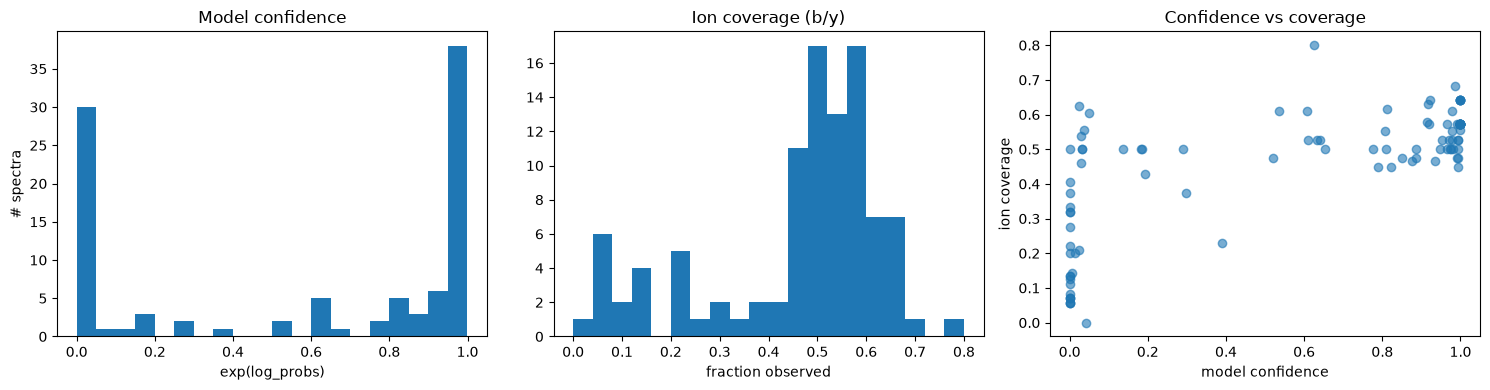

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(preds["model_confidence"], bins=20); ax[0].set(title="Model confidence", xlabel="exp(log_probs)", ylabel="# spectra")
ax[1].hist(preds["ion_coverage"].dropna(), bins=20); ax[1].set(title="Ion coverage (b/y)", xlabel="fraction observed")
ax[2].scatter(preds["model_confidence"], preds["ion_coverage"], alpha=0.6); ax[2].set(title="Confidence vs coverage", xlabel="model confidence", ylabel="ion coverage")
plt.tight_layout(); plt.show()

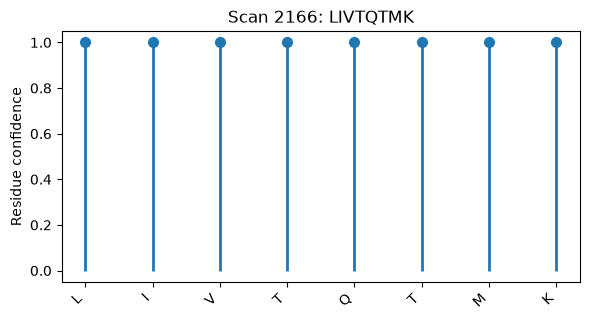

In [ ]:
#@title Per-residue confidence
# InstaNovo reports a per-residue confidence (token log-probability); low-confidence
# residues are where the model is unsure (often where errors or isobaric swaps happen).
import ast

def show_residue_confidence(scan_number):
    row = preds.loc[preds["scan_number"] == scan_number]
    if row.empty:
        print(f"scan {scan_number} not found - pick one from the lists above.")
        return
    row = row.iloc[0]
    tokens = [t.strip() for t in str(row["predictions_tokenised"]).split(",")]
    tlp = np.asarray(ast.literal_eval(row["token_log_probs"]), float)
    conf = np.exp(tlp[:len(tokens)])

    _, ax = plt.subplots(figsize=(max(6, 0.35 * len(tokens)), 3.3)) # slightly closer stems, more vertical room
    markerline, stemlines, _ = ax.stem(range(len(tokens)), conf, basefmt=" ")
    # Bold marker and stem lines
    plt.setp(markerline, markersize=7)
    plt.setp(stemlines, linewidth=2)
    # Make stems closer
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    # Add breathing room at the top
    y_max = min(1.05, max(1, conf.max() + 0.08))
    ax.set_ylim(-0.05, y_max)
    ax.set_ylabel("Residue confidence")
    ax.set_title(f"Scan {scan_number}: {''.join(tokens)}")
    plt.tight_layout(); plt.show()

# most confident prediction
show_residue_confidence(int(preds.sort_values("model_confidence", ascending=False).iloc[0]["scan_number"]))

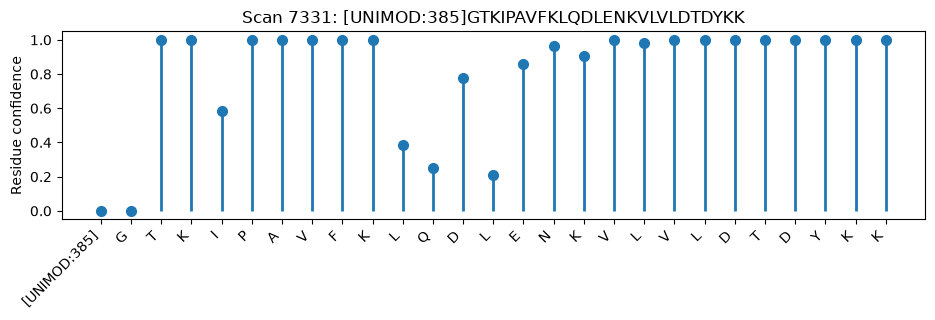

In [ ]:
# least confident prediction
show_residue_confidence(int(preds.sort_values("model_confidence", ascending=False).iloc[-1]["scan_number"]))

### Biological sanity check — does the top hit make sense?
The most confident predictions are dominated by a single peptide, **`LIVTQTMK`**. [PXD058287](https://www.ebi.ac.uk/pride/archive/projects/PXD058287) is **degraded milk whey**, so we'd expect the most intense spectra to come from the most abundant protein.

In [ ]:
#@title Most frequent high-confidence predictions
confident = preds[preds["model_confidence"] >= 0.9]
print(f"{len(confident)} / {len(preds)} predictions with confidence >= 0.9; most frequent peptides:\n")
print(confident["predictions"].value_counts().head(10).to_string())

44 / 100 predictions with confidence >= 0.9; most frequent peptides:

predictions
LIVTQTMK                           18
VYVEELKPTPEGDLEILLQK               14
VGINYWLAHK                          1
ASDISLLDAQSAPLR                     1
VLVLDTDYKK                          1
VATVSLPR                            1
ALPMHIR                             1
SLAM[UNIMOD:35]AASDISLLDAQSAPLR     1
RTPEVDDEALE                         1
VLDTDYKK                            1


So let's look up what it is: we'll query **UniProt's peptide search** (exact match across UniProt — no BLAST needed) and report the hits. Recovering a known protein's peptide **with no database used during sequencing** is a strong sign the *de novo* pipeline is working. *(Needs internet.)*

In [ ]:
#@title Which protein is it? (UniProt peptide search - no BLAST needed)
import urllib.request, urllib.error, json, time

peptide = confident["predictions"].value_counts().idxmax()   # most frequent confident peptide
print("querying UniProt peptide search for:", peptide)

# 1) submit an async exact-peptide search, restricted to Bos taurus (taxId 9913)
r = urllib.request.urlopen(urllib.request.Request(
    "https://peptidesearch.uniprot.org/asyncrest",
    data=f"peps={peptide}&taxIds=9913&lEQi=off&spOnly=off".encode(),
    headers={"Content-Type": "application/x-www-form-urlencoded"}, method="POST"), timeout=60)
job = r.headers["Location"].replace("http://", "https://")

# 2) poll until the job returns results
accs = None
for _ in range(40):
    try:
        resp = urllib.request.urlopen(job, timeout=60)
        if resp.status == 200:
            accs = resp.read().decode().strip().split(","); break
    except urllib.error.HTTPError:
        pass
    time.sleep(2)

# 3) fetch the top hit's name + sequence and check where the peptide sits
if not accs:
    print("No UniProt match (or the service timed out).")
else:
    acc = accs[0]
    j = json.load(urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{acc}.json", timeout=60))
    name = j["proteinDescription"]["recommendedName"]["fullName"]["value"]
    org  = j["organism"]["scientificName"]
    seq  = j["sequence"]["value"]
    sig  = [f for f in j.get("features", []) if f["type"] == "Signal"]
    sig_end = sig[0]["location"]["end"]["value"] if sig else 0
    pos  = seq.find(peptide) + 1
    print(f"\n{peptide}  ->  {acc}: {name} ({org})")
    print(f"  precursor residues {pos}-{pos + len(peptide) - 1}; ends in '{peptide[-1]}' -> tryptic C-terminus: {peptide[-1] in 'KR'}")
    if sig_end:
        where = "N-terminus of the mature protein" if pos == sig_end + 1 else "internal peptide"
        print(f"  signal peptide ends at residue {sig_end} -> mature protein starts at {sig_end + 1}: this is the {where}")
    print(f"  {len(accs)} UniProt match(es) (incl. beta-LG variants): {', '.join(accs)}")

querying UniProt peptide search for: LIVTQTMK

LIVTQTMK  ->  P02754: Beta-lactoglobulin (Bos taurus)
  precursor residues 17-24; ends in 'K' -> tryptic C-terminus: True
  signal peptide ends at residue 16 -> mature protein starts at 17: this is the N-terminus of the mature protein
  7 UniProt match(es) (incl. beta-LG variants): P02754, A0A3Q1LYE8, A0A3Q1M701, A0AAF6Z0B1, A0ABI0NXB9, B5B0D4, Q9TRB9


So **`LIVTQTMK`** is the N-terminal tryptic peptide of mature **bovine β-lactoglobulin**

## Step 7 Calibrate confidence & control FDR with winnow
The model's `log_probs` confidence isn't *calibrated* — a score of 0.9 doesn't literally mean "90% likely correct". [**Winnow**](https://github.com/instadeepai/winnow) recalibrates *de novo* confidence with a **pretrained general model** and estimates a **false discovery rate (FDR)** *without ground-truth labels*, so you can keep only PSMs below a chosen FDR.

**Heads-up:**
Needs **internet**: it downloads a pretrained calibrator from Hugging Face and queries the public **[Koina](https://koina.wilhelmlab.org)** server for fragment-ion predictions.

In [ ]:
#@title Install winnow (confidence calibration & FDR control)
!pip install -q "winnow-fdr>=2.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.8/846.8 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.8/111.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 95.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires grpcio>=1.71.2, but you have grpcio 1.67.1 which is incompatible.
grpcio-sta

In [ ]:
!winnow predict --help

                                                                                
 Usage: winnow predict [OPTIONS]                                                
                                                                                
 Calibrate confidence scores and filter peptide predictions by false discovery  
 rate (FDR).                                                                    
                                                                                
 This command loads your dataset, applies a trained calibrator to improve       
 confidence scores, estimates FDR using your chosen method, and outputs         
 filtered predictions at your target FDR threshold.                             
                                                                                
 Quick start:                                                                   
   winnow predict  # Uses default config from config/predict.yaml               
                            

The pretrained calibrator's Prosit fragment model needs a per-spectrum collision energy and fragmentation type, which aren't in the mzML metadata.
For this run (Q Exactive HF, HCD) the normalized collision energy (NCE) is ~30.
Set these parameters to your acquisition's normalized collision energy for the most accurate fragment-match features.

We also need to increase the number of training samples to train observed retention time to indexed retention time regressors, since our most confident predictions are often duplicates.

In [ ]:
# We set the FDR threshold to 1.0 to return all PSMs
!winnow predict dataset.spectrum_path_or_directory=subset_100.parquet \
                dataset.predictions_path=preds.csv koina.input_constants.collision_energies=30 \
                koina.input_constants.fragmentation_types=HCD \
                output_folder=winnow_results \
                fdr_control.fdr_threshold=1.0 \
                +calibrator.irt_calibration.train_fraction=0.3

[07/29/26 20:48:00] INFO     Starting prediction pipeline.            main.py:67
                    INFO     Prediction configuration: {'dataset':    main.py:68
                             {'spectrum_path_or_directory':                     
                             'subset_100.parquet',                              
                             'predictions_path': 'preds.csv'},                  
                             'calibrator':                                      
                             {'pretrained_model_name_or_path':                  
                             'InstaDeepAI/winnow-general-model',                
                             'cache_dir': None, 'irt_regressor_path':           
                             None, 'irt_calibration':                           
                             {'train_fraction': 0.3}}, 'fdr_control':           
                             {'fdr_threshold': 1.0,                             
                            

In [ ]:
_HEAVY_COLS = {
    "mz_array", "intensity_array", "theoretical_mz", "theoretical_intensity",
    "theoretical_annotation", "ion_matches", "ion_match_intensity", "token_log_probs",
}
metadata = pd.read_csv(
    "winnow_results/metadata.csv",
    usecols=lambda c: c not in _HEAVY_COLS,
)
preds_and_fdr_metrics = pd.read_csv("winnow_results/preds_and_fdr_metrics.csv")
winnow_results = metadata.merge(preds_and_fdr_metrics, on="spectrum_id")

print(winnow_results["calibrated_confidence"].describe())

count    97.000000
mean      0.672516
std       0.368517
min       0.000143
25%       0.418690
50%       0.841015
75%       0.967437
max       0.979058
Name: calibrated_confidence, dtype: float64


In [ ]:
print("PSMs passing 5% FDR:", int((preds_and_fdr_metrics["psm_q_value"] <= 0.05).sum()))
print("PSMs passing 10% FDR:", int((preds_and_fdr_metrics["psm_q_value"] <= 0.1).sum()))
print("PSMs passing 25% FDR:", int((preds_and_fdr_metrics["psm_q_value"] <= 0.25).sum()))

PSMs passing 5% FDR: 47
PSMs passing 10% FDR: 66
PSMs passing 25% FDR: 86


In [ ]:
print("==TOP 10 (most confident after calibration)==")
print(preds_and_fdr_metrics.sort_values("calibrated_confidence", ascending=False).head(10).to_string(index=False))

print("\n==BOTTOM 10 (least confident after calibration)==")
print(preds_and_fdr_metrics.sort_values("calibrated_confidence", ascending=False).tail(10).to_string(index=False))

==TOP 10 (most confident after calibration)==
                                            spectrum_id  prediction  calibrated_confidence  psm_fdr  psm_q_value  psm_pep
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2303    IIVTQTMK               0.979058 0.020942     0.020942 0.020942
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2104    IIVTQTMK               0.976789 0.022077     0.022077 0.023211
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2277    IIVTQTMK               0.976014 0.022713     0.022713 0.023986
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2199    IIVTQTMK               0.975756 0.023096     0.023096 0.024244
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2091    IIVTQTMK               0.975266 0.023423     0.023423 0.024734
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2178    IIVTQTMK               0.974477 0.023773     0.023773 0.025523
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3:2264    IIVTQTMK               0.974474 0.024024 

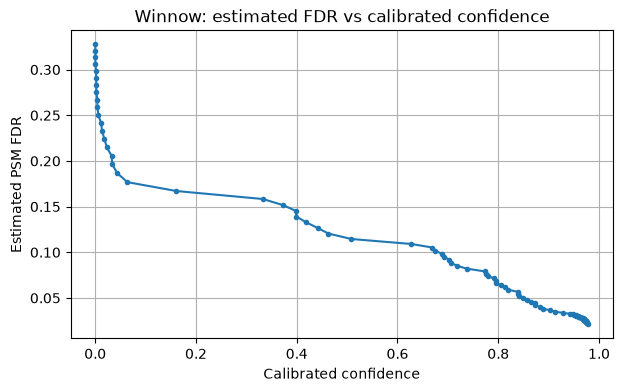

In [ ]:
fdr_curve = preds_and_fdr_metrics.sort_values("calibrated_confidence")
plt.figure(figsize=(7, 4))
plt.plot(fdr_curve["calibrated_confidence"], fdr_curve["psm_fdr"], marker=".")
plt.xlabel("Calibrated confidence")
plt.ylabel("Estimated PSM FDR")
plt.title("Winnow: estimated FDR vs calibrated confidence"); plt.grid(True); plt.show()

### Reading the FDR curve
The curve is **monotonic**: higher calibrated confidence → lower estimated FDR. To control the false discovery rate you pick a target and keep only PSMs **above the matching confidence cutoff**:
- **5% FDR** needs calibrated confidence ≈ **0.87** here → about **44 / 100** PSMs pass.
- relaxing to **10%** drops the cutoff (≈ 0.70) and keeps more; **25%** keeps almost everything.

This is the **precision/recall trade-off made explicit**: a stricter FDR keeps fewer but higher-quality identifications. The key win is that it works **without ground-truth labels** — after calibration the confidence behaves like a real probability of being correct, so "5% FDR" means roughly 5% of the *kept* PSMs are expected to be wrong. For downstream analysis you'd report only the FDR-filtered subset (e.g. the ~44 PSMs at 5% FDR), not all 100 raw predictions.

> ⚠️ The estimate is only as trustworthy as its inputs: a **generic** pretrained calibrator, an **approximate** collision energy, and the non-parametric method's assumption that the calibrated scores really are well-calibrated. Treat the exact cutoffs as indicative, and re-calibrate on your own instrument/data for production use.

In [ ]:
winnow_results.head()

,spectrum_id,prediction_id,confidence,group,delta_mass_ppm,scan_number,precursor_mass,precursor_mz,precursor_charge,retention_time,...,z-score,edit_distance,min_token_probability,std_token_probability,mass_error_da,prediction,calibrated_confidence,psm_fdr,psm_q_value,psm_pep
0,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,0,0.999421,no_group,0.559510,2130,932.535985,467.275269,2,6.114920,...,2.000000,0.000000,0.999555,0.000143,0.000523,IIVTQTMK,0.973992,0.024272,0.024272,0.026008
1,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,1,0.024295,no_group,6539.677587,4757,1683.775609,842.895081,2,10.895786,...,1.999985,0.000000,0.114860,0.265170,-11.024193,IDQWIGMRPGY[UNIMOD:21]EK,0.043910,0.186536,0.186536,0.956090
2,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,2,0.641334,no_group,0.209681,7736,2313.255394,772.092407,3,16.373339,...,1.695545,0.000000,0.642431,0.077911,-0.000486,VYVEEIKPTPEGDIEIIIQK,0.691496,0.095162,0.095162,0.308504
3,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,3,0.978448,no_group,0.101656,5346,1199.645286,400.889038,3,11.912287,...,1.999566,0.000000,0.979028,0.006276,-0.000122,VGINYWIAHK,0.965441,0.028294,0.028294,0.034559
4,20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...,4,0.000001,no_group,11502.291315,9532,2433.352623,812.124817,3,20.149585,...,1.371126,0.090909,0.187581,0.278654,-28.023889,YVIQIIVTKPGEDFAVAEAITK,0.002315,0.275254,0.275254,0.997685


### Follow-on: QC retained PSMs with Winnow metadata

FDR filtering gives you a list to report, but practitioners still inspect individual PSMs before publication or quantitation. Winnow's `metadata.csv` holds _calibration features_ that mirror standard database-search QC (precursor mass error, spectral similarity, retention time) plus de novo-specific signals (beam ambiguity, per-residue confidence).

Step 6 used InstaNovo's raw `model_confidence` and a hand-rolled `ion_coverage` (counting matched b/y peaks). Here we use Winnow's computed features especially `spectral_angle`, `mass_error_da`, and `margin`, which are close to what search engines report and what the calibrator actually learned from.

We'll work on the **5% FDR retained subset** (~47 PSMs on this run), not all raw predictions.

In [ ]:
FDR_THRESHOLD = 0.05

if "ion_coverage" not in winnow_results.columns and "ion_coverage" in preds.columns:
    winnow_results = winnow_results.merge(
        preds[["scan_number", "ion_coverage"]], on="scan_number", how="left"
    )

retained = winnow_results[winnow_results["psm_q_value"] <= FDR_THRESHOLD].copy()
rejected = winnow_results[winnow_results["psm_q_value"] > FDR_THRESHOLD].copy()
print(f"Retained at {FDR_THRESHOLD:.0%} FDR: {len(retained)} / {len(winnow_results)} PSMs")

QC_METRICS = [
    "calibrated_confidence", "spectral_angle", "complementary_ion_count",
    "max_ion_gap", "margin", "edit_distance", "min_token_probability", "irt_error",
]

def _qc_summary(df, label):
    row = {"group": label, "n": len(df)}
    for col in QC_METRICS:
        row[col] = df[col].median()
    row["|mass_error_da|"] = df["mass_error_da"].abs().median()
    row["|delta_mass_ppm|"] = df["delta_mass_ppm"].abs().median()
    return row

summary = pd.DataFrame([
    _qc_summary(retained, "retained (q≤5%)"),
    _qc_summary(rejected, "rejected"),
]).set_index("group")
display(summary.round(3))

Retained at 5% FDR: 47 / 97 PSMs


,n,calibrated_confidence,spectral_angle,complementary_ion_count,max_ion_gap,margin,edit_distance,min_token_probability,irt_error,|mass_error_da|,|delta_mass_ppm|
group,,,,,,,,,,,
retained (q≤5%),47,0.967,0.674,2.0,128.059,0.986,0.000,0.994,1.934,0.001,0.56
rejected,50,0.430,0.574,1.0,129.043,0.034,0.042,0.198,7.191,0.002,1.00


#### Fragment-ion evidence
Winnow predicts a theoretical spectrum using [Prosit](https://koina.wilhelmlab.org/docs#post-/Prosit_2025_intensity_22PTM/infer) (Koina, CE≈30 / HCD in our command) and compares it to the observed spectrum:
- **`spectral_angle`** — normalized spectral similarity
- **`complementary_ion_count`** / **`max_ion_gap`** — how complete the b/y ion ladder is

High calibrated confidence with low `spectral_angle` is a similar red flag as Step 6's "high confidence, low coverage"

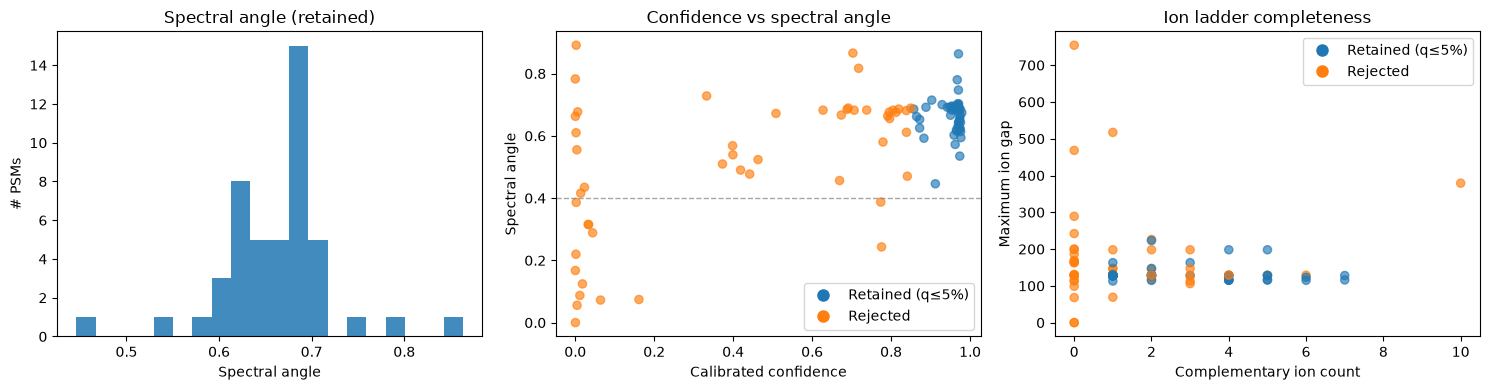

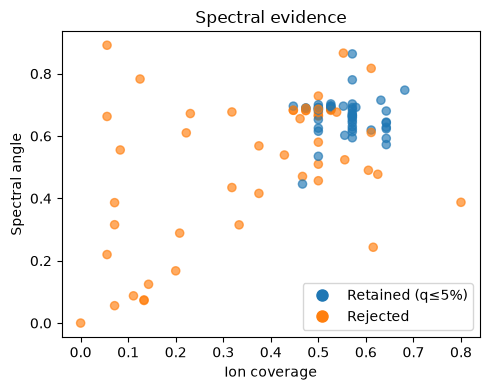

In [ ]:
pass_mask = winnow_results["psm_q_value"] <= FDR_THRESHOLD
colors = np.where(pass_mask, "C0", "C1")

import matplotlib.lines as mlines

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(retained["spectral_angle"], bins=20, color="C0", alpha=0.85)
ax[0].set(title="Spectral angle (retained)", xlabel="Spectral angle", ylabel="# PSMs")

# Scatter: Calibrated confidence vs spectral angle
scatter1 = ax[1].scatter(
    winnow_results["calibrated_confidence"], winnow_results["spectral_angle"],
    c=colors, alpha=0.65, s=35,
)
ax[1].axhline(0.4, color="gray", ls="--", lw=1, alpha=0.7)
ax[1].set(title="Confidence vs spectral angle", xlabel="Calibrated confidence", ylabel="Spectral angle")

legend_handles = [
    mlines.Line2D([], [], color="C0", marker='o', linestyle='None', markersize=8, label=f'Retained (q≤{FDR_THRESHOLD:.0%})'),
    mlines.Line2D([], [], color="C1", marker='o', linestyle='None', markersize=8, label='Rejected'),
]
ax[1].legend(handles=legend_handles)

# Scatter: Ion ladder (retained & rejected, colored by pass/fail)
scatter2 = ax[2].scatter(
    winnow_results["complementary_ion_count"], winnow_results["max_ion_gap"],
    c=colors, alpha=0.65, s=35,
)
ax[2].set(title="Ion ladder completeness", xlabel="Complementary ion count", ylabel="Maximum ion gap")
# Legend for this plot as well
ax[2].legend(handles=legend_handles)

plt.tight_layout(); plt.show()

if "ion_coverage" in winnow_results.columns:
    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(winnow_results["ion_coverage"], winnow_results["spectral_angle"], c=colors, alpha=0.65, s=35)
    ax.set(xlabel="Ion coverage", ylabel="Spectral angle", title="Spectral evidence")
    # Add legend for the scatter plot color meanings
    legend_handles2 = [
        mlines.Line2D([], [], color="C0", marker='o', linestyle='None', markersize=8, label=f'Retained (q≤{FDR_THRESHOLD:.0%})'),
        mlines.Line2D([], [], color="C1", marker='o', linestyle='None', markersize=8, label='Rejected'),
    ]
    ax.legend(handles=legend_handles2)
    plt.tight_layout(); plt.show()

#### Precursor mass accuracy
Winnow reports isotope-corrected signed neutral-mass error in Daltons.

Confident PSMs should cluster near 0 Da. Errors of even a few Da usually mean wrong sequence, modification or isotope/charge assignment, regardless of model confidence.

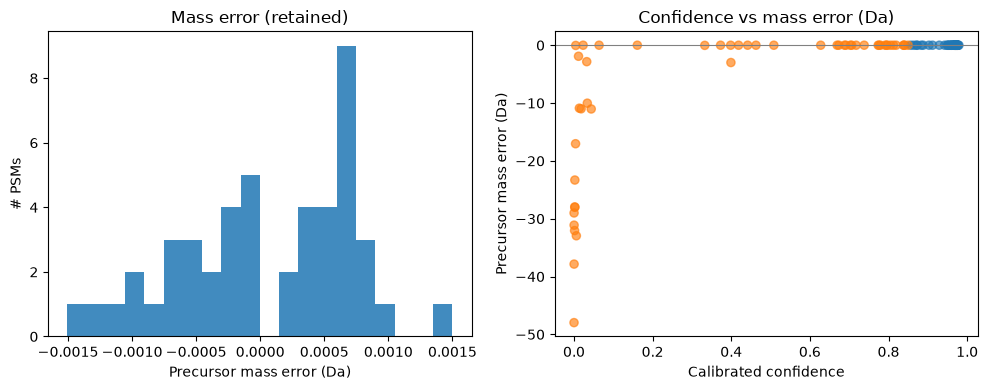

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(retained["mass_error_da"], bins=20, color="C0", alpha=0.85)
ax[0].set(title="Mass error (retained)", xlabel="Precursor mass error (Da)", ylabel="# PSMs")

ax[1].scatter(
    winnow_results["calibrated_confidence"], winnow_results["mass_error_da"],
    c=colors, alpha=0.65, s=35,
)
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set(title="Confidence vs mass error (Da)", xlabel="Calibrated confidence", ylabel="Precursor mass error (Da)")
plt.tight_layout(); plt.show()

#### De novo ambiguity
When InstaNovo exports multiple beam candidates, among other features, Winnow computes:
- **`margin`** — probability gap between top-1 and top-2 sequences
- **`min_token_probability`** — weakest residue in the top prediction

Low margin on a retained PSM means several similar sequences competed.

A negative margin results from InstaNovo's internal beam ranking system: sort by precursor mass fit first, then secondly by confidence.

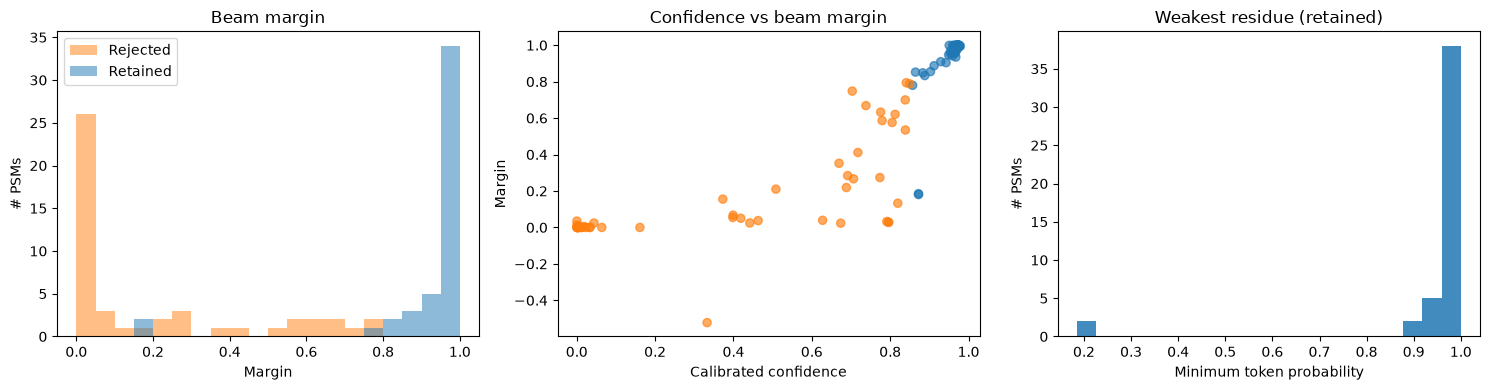

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
bins = np.linspace(0, 1, 21)
ax[0].hist(rejected["margin"], bins=bins, alpha=0.5, label="Rejected", color="C1")
ax[0].hist(retained["margin"], bins=bins, alpha=0.5, label="Retained", color="C0")
ax[0].legend(); ax[0].set(title="Beam margin", xlabel="Margin", ylabel="# PSMs")

ax[1].scatter(
    winnow_results["calibrated_confidence"], winnow_results["margin"],
    c=colors, alpha=0.65, s=35,
)
ax[1].set(title="Confidence vs beam margin", xlabel="Calibrated confidence", ylabel="Margin")

ax[2].hist(retained["min_token_probability"], bins=20, color="C0", alpha=0.85)
ax[2].set(title="Weakest residue (retained)", xlabel="Minimum token probability", ylabel="# PSMs")
plt.tight_layout(); plt.show()

#### Retention-time consistency
Winnow fits a per-run RT→iRT regressor on high-confidence PSMs (no database labels needed). Large **`irt_error`** on a retained PSM can flag a wrong sequence or modification.

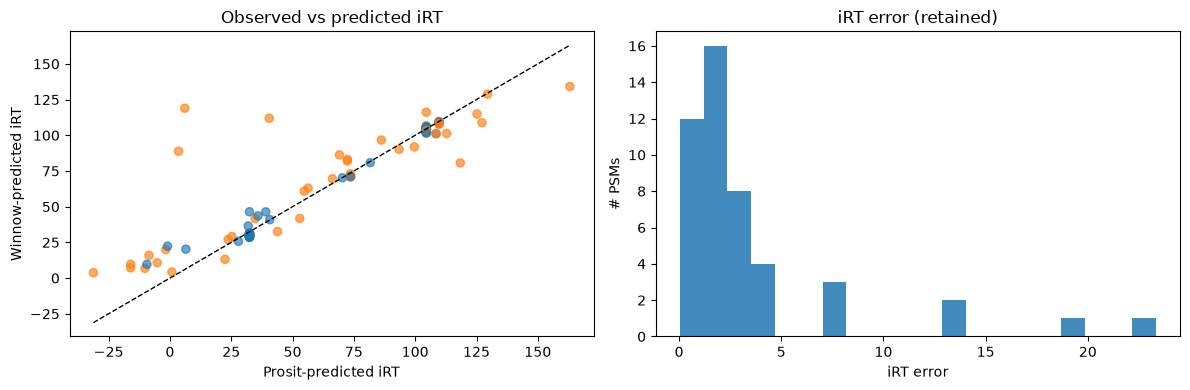

In [ ]:
irt_ok = ~winnow_results["is_missing_irt_error"].astype(bool)
irt_df = winnow_results.loc[irt_ok]
irt_ret = retained.loc[~retained["is_missing_irt_error"].astype(bool)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
lim = [irt_df["iRT"].min(), irt_df["iRT"].max()]
ax[0].scatter(
    irt_df["iRT"], irt_df["predicted iRT"],
    c=np.where(irt_df["psm_q_value"] <= FDR_THRESHOLD, "C0", "C1"), alpha=0.65, s=35,
)
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set(title="Observed vs predicted iRT", xlabel="Prosit-predicted iRT", ylabel="Winnow-predicted iRT")

ax[1].hist(irt_ret["irt_error"], bins=20, color="C0", alpha=0.85)
ax[1].set(title="iRT error (retained)", xlabel="iRT error", ylabel="# PSMs")
plt.tight_layout(); plt.show()

#### Triage and next steps
Even among FDR-retained PSMs, simple heuristics catch cases worth manual review. Feel free to change these flag values and examine retained PSMs.

In [ ]:
flags = (
    (retained["spectral_angle"] < 0.4)
    | (retained["mass_error_da"].abs() > 0.02)
    | (retained["irt_error"] > 10)
)
review_cols = [
    "scan_number", "prediction", "calibrated_confidence", "psm_q_value",
    "spectral_angle", "ion_coverage", "mass_error_da", "margin",
    "min_token_probability", "std_token_probability", "irt_error",
]
review = retained.loc[flags, review_cols].sort_values("calibrated_confidence", ascending=False)
print(f"Retained PSMs flagged for manual review: {len(review)} / {len(retained)}")
display(review.round(4))

Retained PSMs flagged for manual review: 4 / 47


,scan_number,prediction,calibrated_confidence,psm_q_value,spectral_angle,ion_coverage,mass_error_da,margin,min_token_probability,std_token_probability,irt_error
87,1525,IIVTQTM[UNIMOD:35]K,0.9622,0.0286,0.5723,0.6429,-0.0009,0.9986,0.9994,0.0002,13.7806
33,3469,IIVTQTMK,0.9506,0.0315,0.6663,0.5714,-0.0007,0.9991,0.9994,0.0002,14.0186
80,1664,IDAINENK,0.8831,0.0401,0.5924,0.6429,-0.0003,0.8485,0.9268,0.0240,23.3441
71,847,VIDTDYKK,0.8646,0.0460,0.6619,0.5714,-0.0006,0.8523,0.9317,0.0223,19.0085
